In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

chemin = r"\\frfs.sedes.inditex.grp\Rhome$\eliselc.SEDES\Descargas\dataset-festival.csv"

df = pd.read_csv(
    chemin,
    sep=";",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("'", "").str.replace("é", "e")
print(df.columns.tolist())

['\ufeffnom_du_festival', 'envergure_territoriale', 'region_principale_de_deroulement', 'departement_principal_de_deroulement', 'commune_principale_de_deroulement', 'code_postal_(de_la_commune_principale_de_deroulement)', 'code_insee_commune', 'code_insee_epci', 'libelle_epci', 'numero_de_voie', 'type_de_voie_(rue,_avenue,_boulevard,_etc.)', 'nom_de_la_voie', 'adresse_postale', 'complement_dadresse_(facultatif)', 'site_internet_du_festival', 'adresse_e-mail', 'decennie_de_creation_du_festival', 'annee_de_creation_du_festival', 'discipline_dominante', 'sous-categorie_spectacle_vivant', 'sous-categorie_musique', 'sous-categorie_musique_cnm', 'sous-categorie_cinema_et_audiovisuel', 'sous-categorie_arts_visuels_et_arts_numeriques', 'sous-categorie_livre_et_litterature', 'periode_principale_de_deroulement_du_festival', 'identifiant_agence_a', 'identifiant', 'geocodage_xy', 'identifiant_cnm']


In [3]:
print(df.head())
print(df.columns.tolist())
print(df.info())

                               ﻿nom_du_festival envergure_territoriale  \
0                    Des Planches et des Vaches                    NaN   
1                    Festival celte en Gevaudan              Régionale   
2  Festival International de Châteauroux - DARC         Interrégionale   
3                      Contre-plongées de l'été                    NaN   
4                     Festival des Filets Bleus                    NaN   

  region_principale_de_deroulement departement_principal_de_deroulement  \
0                        Normandie                             Calvados   
1             Auvergne-Rhône-Alpes                          Haute-Loire   
2              Centre-Val de Loire                                Indre   
3             Auvergne-Rhône-Alpes                          Puy-de-Dôme   
4                         Bretagne                            Finistère   

  commune_principale_de_deroulement  \
0            Hérouville-Saint-Clair   
1                         

In [4]:
df.dtypes

nom_du_festival                                          object
envergure_territoriale                                    object
region_principale_de_deroulement                          object
departement_principal_de_deroulement                      object
commune_principale_de_deroulement                         object
code_postal_(de_la_commune_principale_de_deroulement)     object
code_insee_commune                                        object
code_insee_epci                                           object
libelle_epci                                              object
numero_de_voie                                            object
type_de_voie_(rue,_avenue,_boulevard,_etc.)               object
nom_de_la_voie                                            object
adresse_postale                                           object
complement_dadresse_(facultatif)                          object
site_internet_du_festival                                 object
adresse_e-mail            

C:\Users\local_eliselc\Temp\ipykernel_25296\1935237737.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette='viridis')


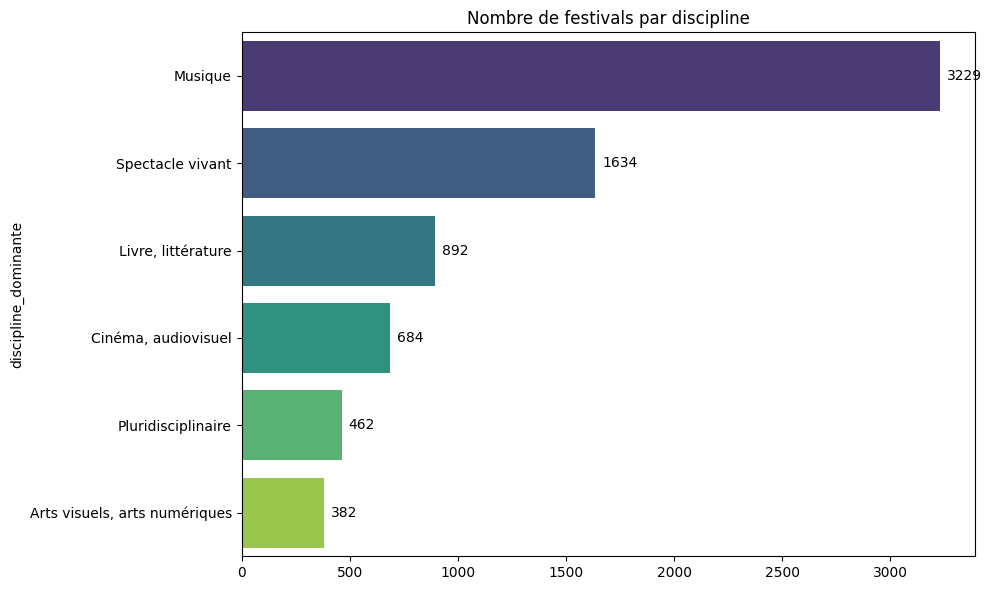

In [5]:
counts = df['discipline_dominante'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=counts.values, y=counts.index, palette='viridis')

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_width())}",
        (bar.get_width(), bar.get_y() + bar.get_height()/2),
        va='center',
        ha='left',
        xytext=(5,0),
        textcoords='offset points'
    )

plt.title("Nombre de festivals par discipline")
plt.tight_layout()
plt.show()

C:\Users\local_eliselc\Temp\ipykernel_25296\1107144429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_regions.values, y=top_regions.index, palette='coolwarm')


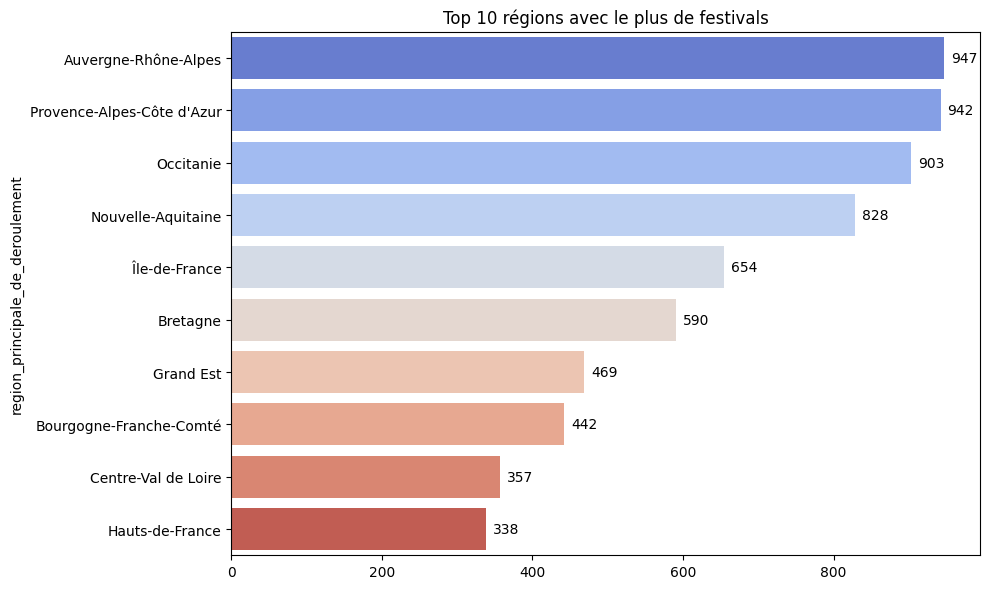

In [6]:
top_regions = df['region_principale_de_deroulement'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_regions.values, y=top_regions.index, palette='coolwarm')

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_width())}",
        (bar.get_width(), bar.get_y() + bar.get_height()/2),
        va='center',
        ha='left',
        xytext=(5,0),
        textcoords='offset points'
    )

plt.title("Top 10 régions avec le plus de festivals")
plt.tight_layout()
plt.show()

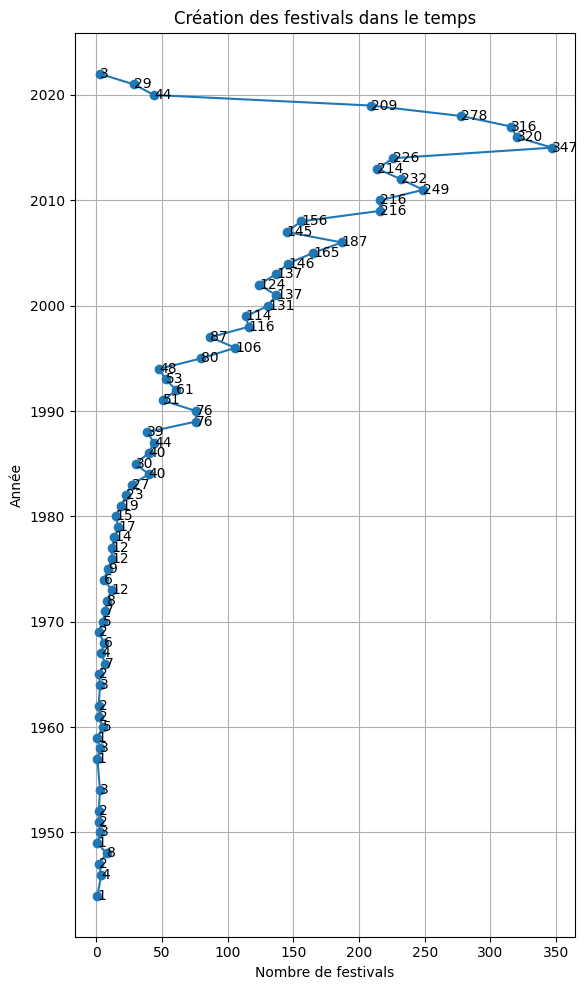

In [7]:
df['annee_de_creation_du_festival'] = pd.to_numeric(
    df['annee_de_creation_du_festival'], errors='coerce'
)

# Filtrer entre 1940 et 2024
df_year = df[
    (df['annee_de_creation_du_festival'] >= 1940) &
    (df['annee_de_creation_du_festival'] <= 2024)
]

counts = df_year['annee_de_creation_du_festival'].value_counts().sort_index()

plt.figure(figsize=(6,10))
plt.plot(counts.values, counts.index, marker='o')

# Data labels
for x, y in zip(counts.values, counts.index):
    plt.text(x, y, str(int(x)), va='center', ha='left')

plt.title("Création des festivals dans le temps")
plt.xlabel("Nombre de festivals")
plt.ylabel("Année")
plt.grid(True)
plt.tight_layout()
plt.show()

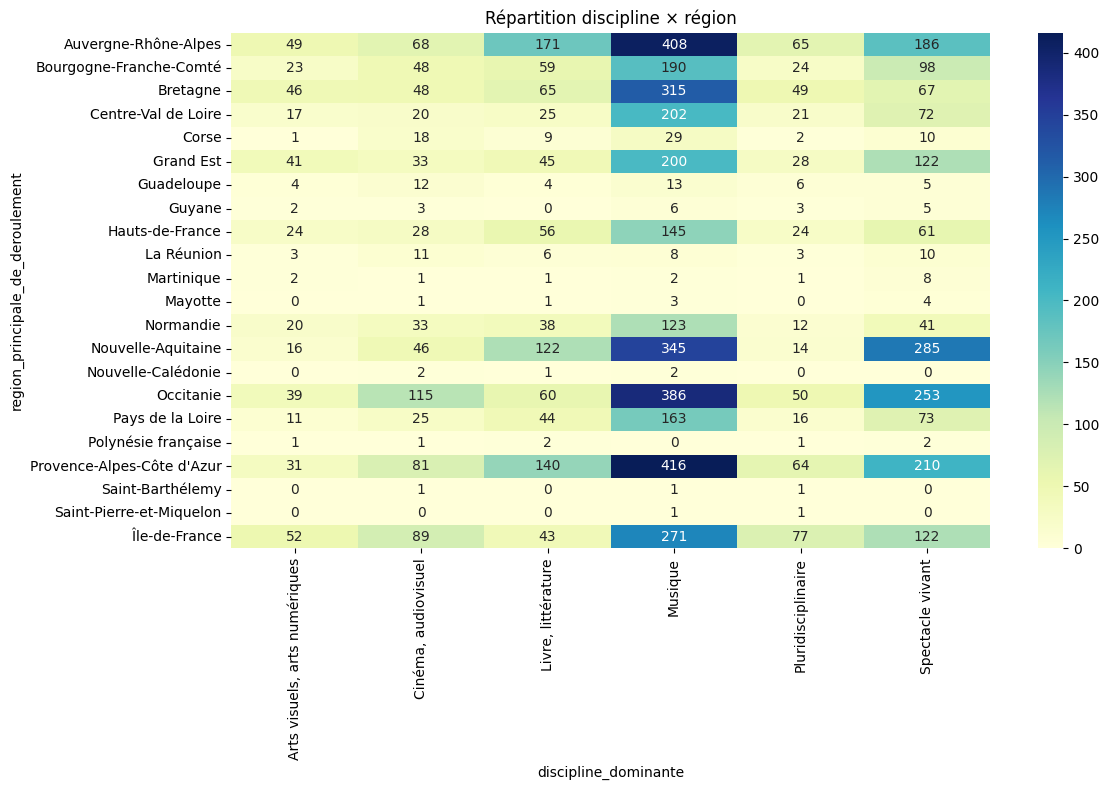

In [8]:
pivot = pd.crosstab(
    df['region_principale_de_deroulement'],
    df['discipline_dominante']
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt="d", cmap='YlGnBu')

plt.title("Répartition discipline × région")
plt.tight_layout()
plt.show()

In [9]:
# Vérifier le nom exact de la colonne
print(df.columns)

# Remplacer ici par le bon nom (ex: 'nom_du_festival ')
nom_col = [col for col in df.columns if 'festival' in col.lower()][0]

df_plot = df.copy()
df_plot['annee_de_creation_du_festival'] = pd.to_numeric(
    df_plot['annee_de_creation_du_festival'], errors='coerce'
)

df_plot = df_plot.dropna(subset=['annee_de_creation_du_festival', nom_col])

# Top 10 plus anciens
plus_anciens = df_plot.sort_values('annee_de_creation_du_festival').head(10)

df.columns = df.columns.str.strip()
nom_col = [col for col in df.columns if 'festival' in col.lower()][0]

table = (
    df[[nom_col, 'annee_de_creation_du_festival']]
    .assign(annee_de_creation_du_festival=lambda x: pd.to_numeric(x['annee_de_creation_du_festival'], errors='coerce'))
    .dropna()
    .sort_values('annee_de_creation_du_festival')
    .rename(columns={
        nom_col: 'Nom du festival',
        'annee_de_creation_du_festival': 'Année de création'
    })
    .reset_index(drop=True)
)

table.head(10)

Index(['﻿nom_du_festival', 'envergure_territoriale',
       'region_principale_de_deroulement',
       'departement_principal_de_deroulement',
       'commune_principale_de_deroulement',
       'code_postal_(de_la_commune_principale_de_deroulement)',
       'code_insee_commune', 'code_insee_epci', 'libelle_epci',
       'numero_de_voie', 'type_de_voie_(rue,_avenue,_boulevard,_etc.)',
       'nom_de_la_voie', 'adresse_postale', 'complement_dadresse_(facultatif)',
       'site_internet_du_festival', 'adresse_e-mail',
       'decennie_de_creation_du_festival', 'annee_de_creation_du_festival',
       'discipline_dominante', 'sous-categorie_spectacle_vivant',
       'sous-categorie_musique', 'sous-categorie_musique_cnm',
       'sous-categorie_cinema_et_audiovisuel',
       'sous-categorie_arts_visuels_et_arts_numeriques',
       'sous-categorie_livre_et_litterature',
       'periode_principale_de_deroulement_du_festival', 'identifiant_agence_a',
       'identifiant', 'geocodage_xy', 'ident

,Nom du festival,Année de création
0,Carnaval de Limoux,1604.0
1,Chorégies d'Orange,1869.0
2,Festival de théâtre,1874.0
3,Festival des Filets Bleus,1905.0
4,La Félibrée,1920.0
5,Cornouaille,1923.0
6,La Fête de l'Humanité,1930.0
7,Festival folklorique international d'Amélie-le...,1935.0
8,Festival de Royaumont,1944.0
9,Fête du château,1946.0


In [10]:
df.columns = df.columns.str.strip()
nom_col = [col for col in df.columns if 'festival' in col.lower()][0]

table_recents = (
    df[[nom_col, 'annee_de_creation_du_festival']]
    .assign(annee_de_creation_du_festival=lambda x: pd.to_numeric(x['annee_de_creation_du_festival'], errors='coerce'))
    .dropna()
    .sort_values('annee_de_creation_du_festival', ascending=False)
    .rename(columns={
        nom_col: 'Nom du festival',
        'annee_de_creation_du_festival': 'Année de création'
    })
    .reset_index(drop=True)
)

table_recents.head(10)

,Nom du festival,Année de création
0,Son et lumière de Bourbon-l'Archambault,31564.0
1,L'ila dels poetes,20198.0
2,Equinocci,2022.0
3,Le festival Les AnthropoScènes,2022.0
4,Sériège jazz festival,2022.0
5,Festival de danse à Saint-Hilaire-d’Ozilhan,2021.0
6,Corsica madness,2021.0
7,Castelpop,2021.0
8,Chemins de traverses,2021.0
9,Au large festival,2021.0


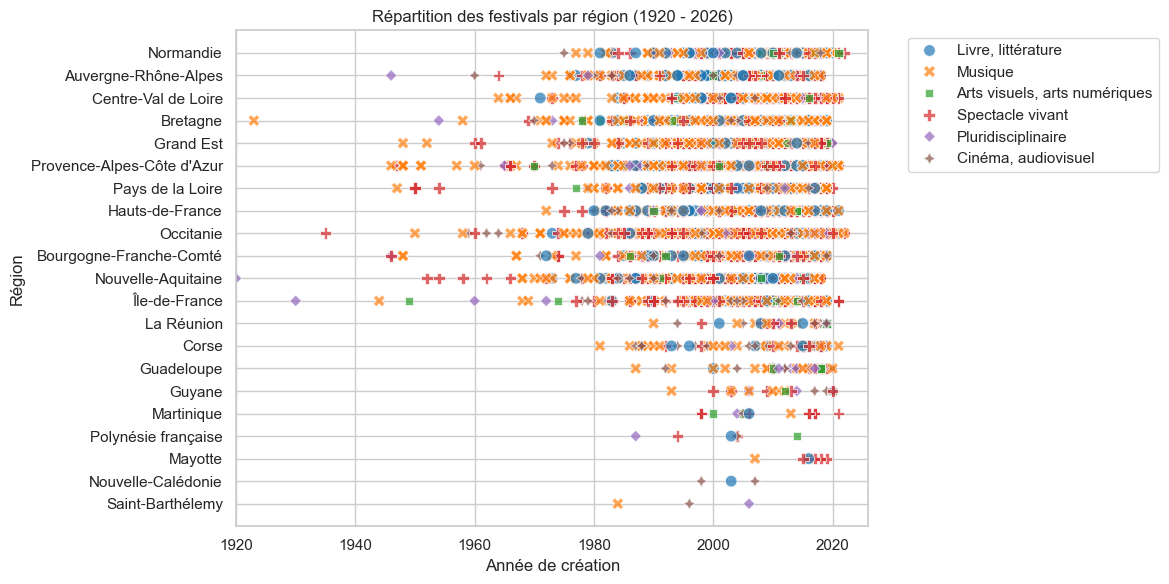

In [21]:
df_plot = df.copy()
df_plot = df.copy()

df_plot['annee_de_creation_du_festival'] = pd.to_numeric(
    df_plot['annee_de_creation_du_festival'], errors='coerce'
)

df_plot = df_plot.dropna(subset=['annee_de_creation_du_festival', 'region_principale_de_deroulement'])

# Style fond blanc + grille
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_plot,
    x='annee_de_creation_du_festival',
    y='region_principale_de_deroulement',
    hue='discipline_dominante',
    style='discipline_dominante',   # 👉 symboles différents
    palette='tab10',
    s=70,
    alpha=0.7
)

plt.xlim(1920, 2026)

plt.title("Répartition des festivals par région (1920 - 2026)")
plt.xlabel("Année de création")
plt.ylabel("Région")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

(1920.0, 2026.0)

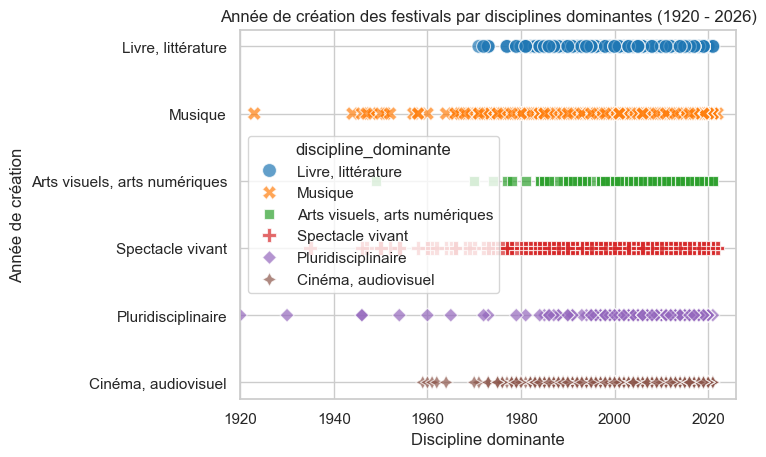

In [50]:
sns.scatterplot(
    data=df_plot,
    x='annee_de_creation_du_festival',
    y='discipline_dominante',
    hue='discipline_dominante',
    style='discipline_dominante',
    palette='tab10',
    s=100,
    alpha=0.7
)
plt.title("Année de création des festivals par disciplines dominantes (1920 - 2026)")
plt.xlabel("Discipline dominante")
plt.ylabel("Année de création")
plt.xlim(1920, 2026)



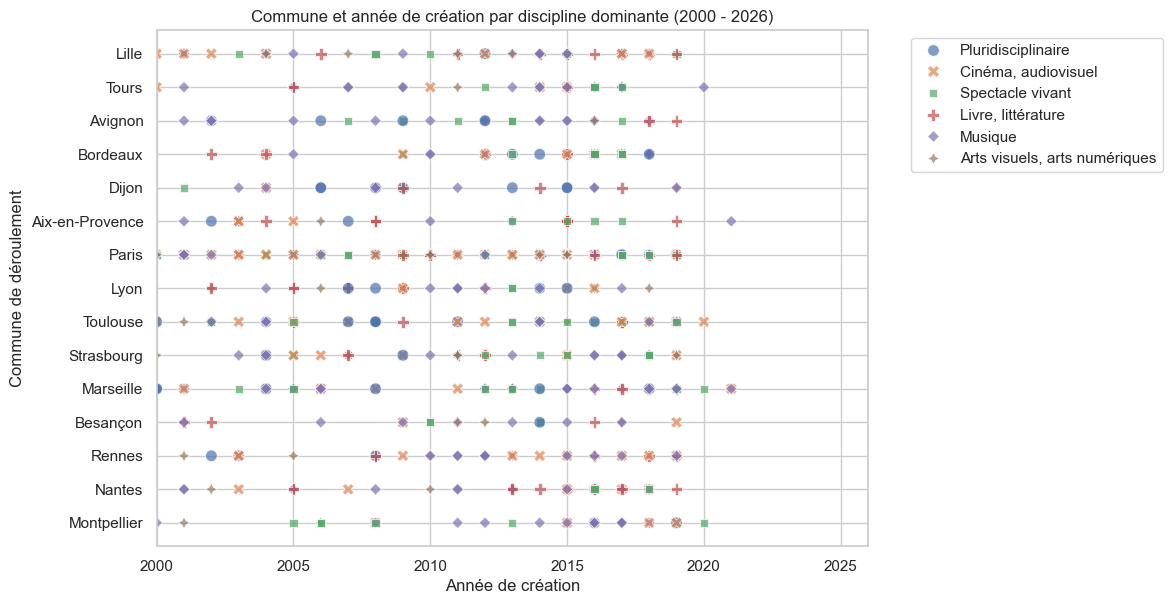

In [55]:
top_villes = df_plot['commune_principale_de_deroulement'].value_counts().head(15).index
df_ville = df_plot[df_plot['commune_principale_de_deroulement'].isin(top_villes)]

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_ville,
    x='annee_de_creation_du_festival',
    y='commune_principale_de_deroulement',
    hue='discipline_dominante',
    style='discipline_dominante',
    s=70,
    alpha=0.7
)

plt.xlim(2000, 2026)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.title("Commune et année de création par discipline dominante (2000 - 2026)")
plt.xlabel("Année de création")
plt.ylabel("Commune de déroulement")
plt.show()

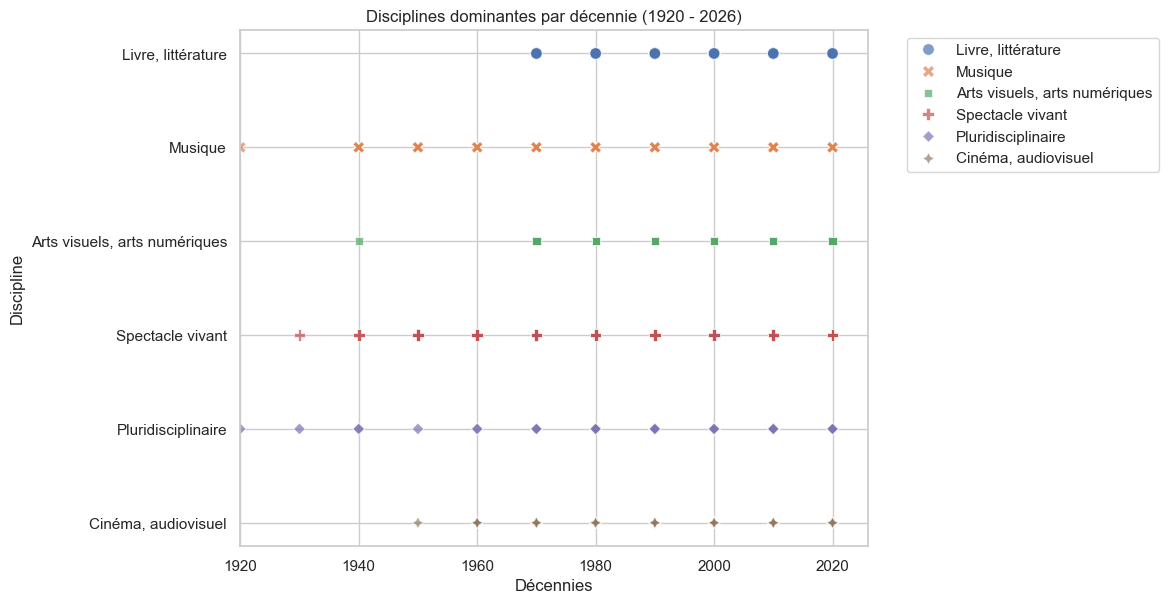

In [56]:
df_plot['decennie'] = (df_plot['annee_de_creation_du_festival']//10)*10

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_plot,
    x='decennie',
    y='discipline_dominante',
    hue='discipline_dominante',
    style='discipline_dominante',
    s=70,
    alpha=0.7
)

plt.xlim(1920, 2026)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.title("Disciplines dominantes par décennie (1920 - 2026)")
plt.xlabel("Décennies")
plt.ylabel("Discipline")

plt.show()

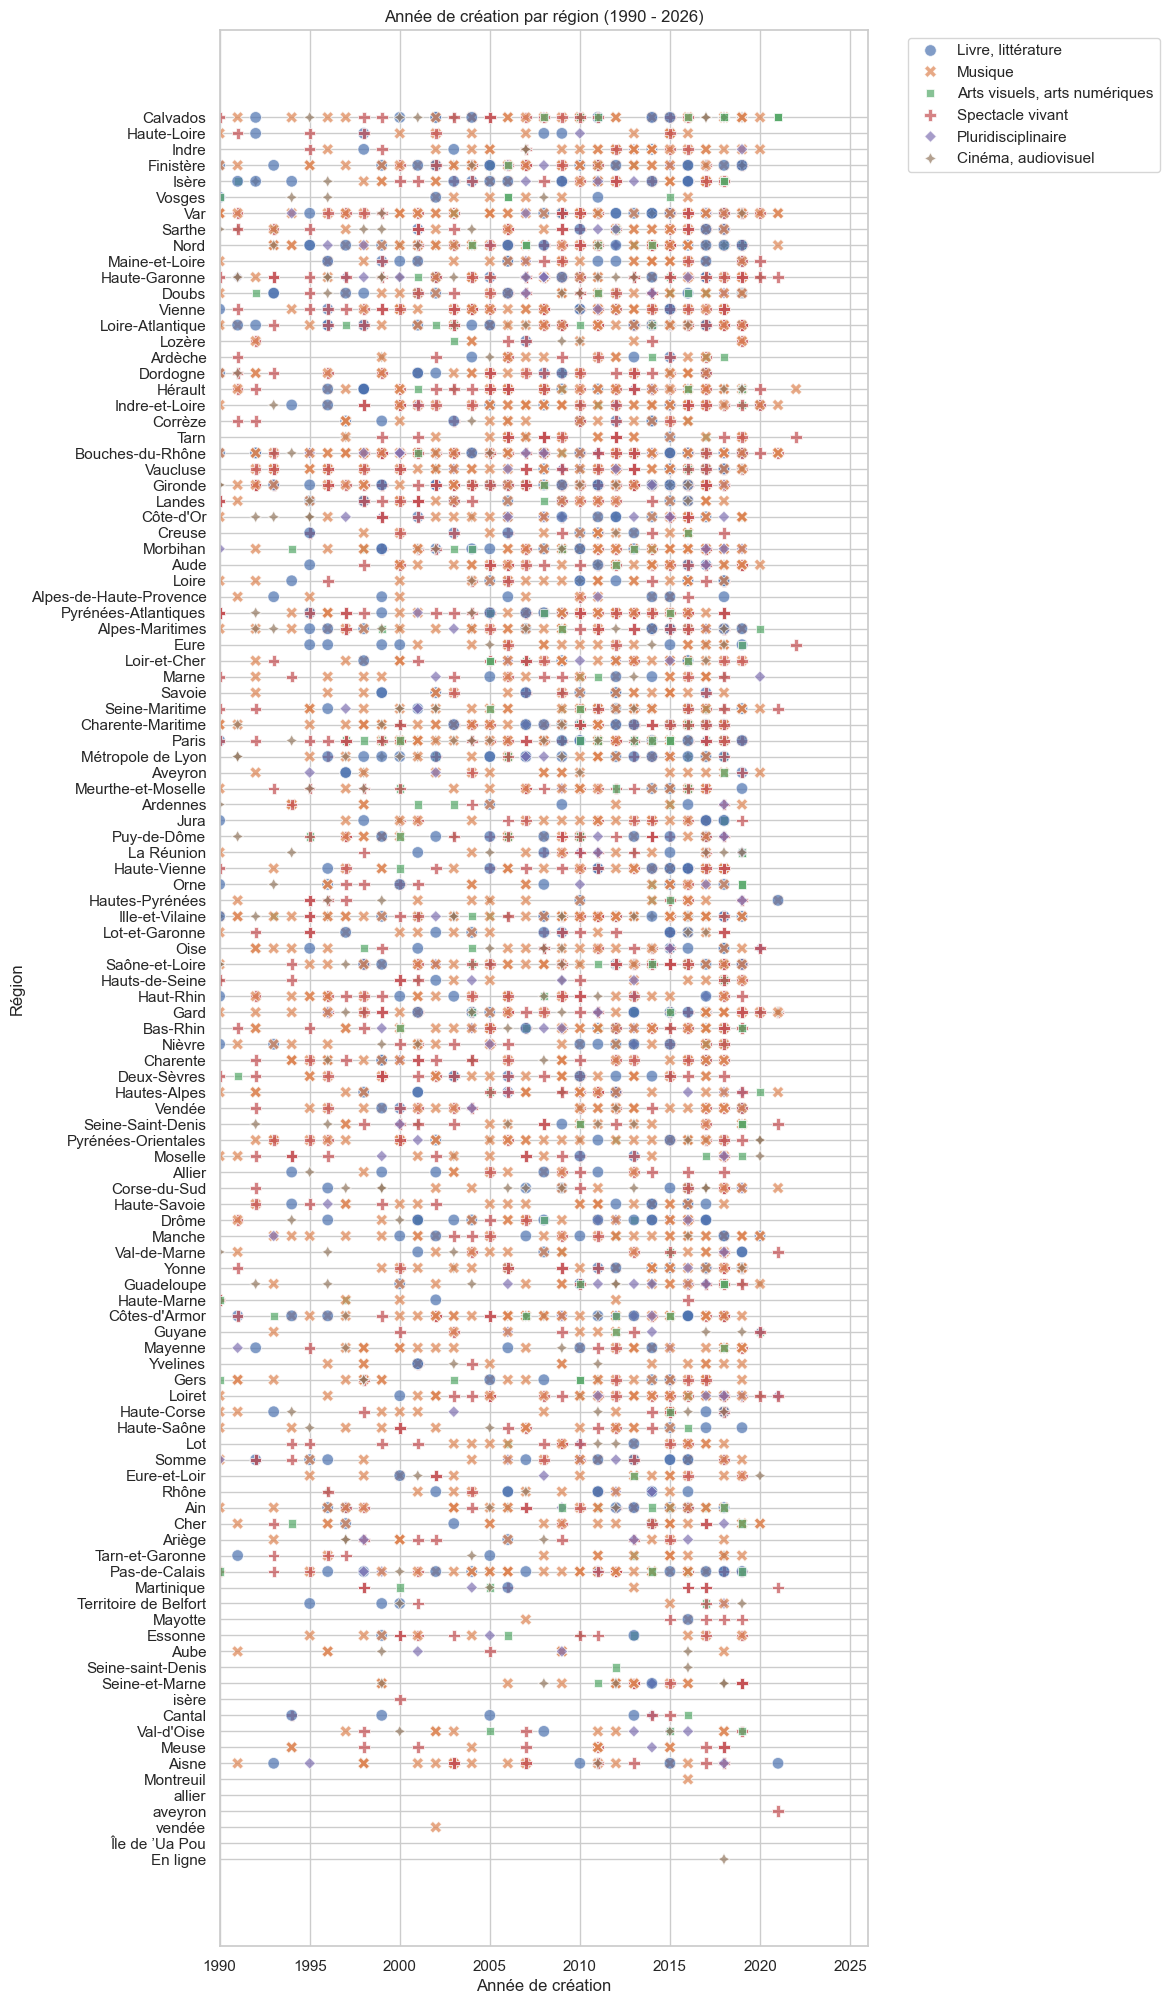

In [57]:
plt.figure(figsize=(12,20))

sns.scatterplot(
    data=df_plot,
    x='annee_de_creation_du_festival',
    y='departement_principal_de_deroulement',
    hue='discipline_dominante',
    style='discipline_dominante',
    s=70,
    alpha=0.7
)

plt.xlim(1990, 2026)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.title("Année de création par région (1990 - 2026)")
plt.xlabel("Année de création")
plt.ylabel("Région")

plt.show()